In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **¿Que es un arbol de decisión?**


Un árbol de decisión es un modelo de aprendizaje automático que utiliza una estructura jerárquica de decisiones basada en condiciones sobre las variables de entrada, con el objetivo de predecir un resultado. Este modelo divide los datos en subconjuntos más pequeños mediante reglas simples, permitiendo interpretar fácilmente cómo se llega a una predicción.


Un árbol de decisión es un modelo de Machine Learning que toma decisiones usando reglas simples tipo:

  **“Si pasa esto → entonces ocurre esto otro”**

Es como un diagrama de flujo que divide los datos en pasos hasta llegar a una predicción.

**ESTRUCTURA DEL ARBOL**

El arbol se compone por tres partes:



1.   **Nodo raíz (inicio):** Es la primera decisión importante.
2.   **Ramas (decisiones):** Son los caminos según la respuesta.
1.   **Hojas (Resultado final):** Aquí esta predicción.






**Para que sirve**



*   Predecir valores (regresión).
*   Clasificar (sí/no, tipo clientes, etc).
*   Entender decisiones.





#**¿Que es Random Forest?**

Random Forest es un modelo de aprendizaje automático que construye múltiples árboles de decisión y combina sus resultados para mejorar la precisión de las predicciones, ya sea mediante votación en problemas de clasificación o promediando resultados en problemas de regresión.

#**Modelamiento Predictivo de la Demanda utilizando Árboles de Decisión**

In [4]:
#INTERPRETACION DE UN ARBOL DE REGRESIÓN PARA PREDICCIÓN DE DEMANDA
#IMPORTACIÓN DE LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import plot_tree
import seaborn as sns

In [5]:
#1.- CREAR DATOS SINTETICOS
np.random.seed(42)
n= 1000

precio= np.random.uniform(10, 100, n)
promocion=np.random.binomial(1,0.3,n)
estacionalidad = np.random.choice(["alta","media","baja"], n)
canal =np.random.choice(["online","tienda"],n)
historial_compras = np.random.uniform(100, 20, n)

In [6]:
# CREAR DATAFRAME
df= pd.DataFrame({
    "precio": precio,
    "promocion": promocion,
    "estacionalidad": estacionalidad,
    "canal": canal,
    "historial_compras": historial_compras
})

In [7]:
#CODIFICAR VARIABLES CATEGORICAS
df= pd.get_dummies(df, columns=["estacionalidad","canal"], drop_first=False)

In [8]:
# CREAR VARIABLE OBJETIVO
df['demanda'] = (
    200
    - 3 * df['precio']
    + 20 * df['promocion']
    + 0.5 * df['historial_compras']
    + 10 * df['estacionalidad_media']
    + 25 * df['estacionalidad_alta']
    + 15 * df['canal_tienda']
    + np.random.normal(0, 10, n)
)

In [9]:
# 2.- SEPARAR X e Y
X = df.drop(columns='demanda')
y = df['demanda']

In [10]:
# 3.- DIVIDIR LOS DATOS DE ENTRENAMIENTO Y PRUEBA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
#4.- ENTRENAR MODELO
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [12]:
#5.- IMPORTANCIA POR IMPUREZA
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)

In [13]:
#IMPORTANCIA LAS TRES MAS IMPORTANTES
print("Tres variables más importantes en la predicción de demanda:")
print(importancias_ordenadas.head(3))

Tres variables más importantes en la predicción de demanda:
precio               0.948548
historial_compras    0.027597
promocion            0.009238
dtype: float64


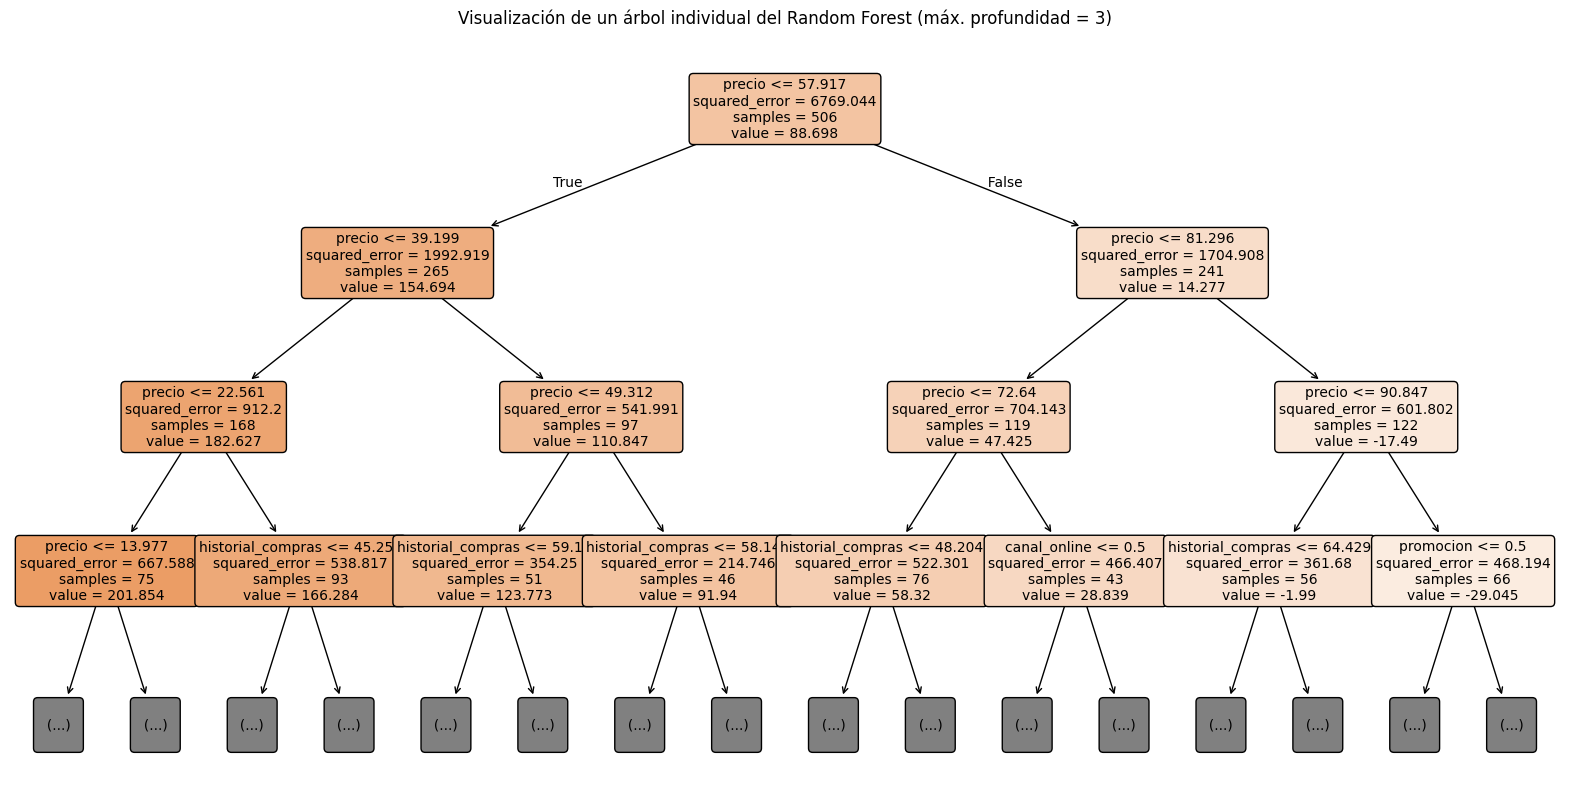

In [14]:
#6.- VISUALIZAR UNO DE LOS ARBOLES DEL BOSQUE

plt.figure(figsize=(20, 10))
plot_tree(modelo.estimators_[0],
          feature_names=X.columns,
          filled=True,
          rounded=True,
          max_depth=3,   # mostrar solo los primeros niveles para claridad
          fontsize=10)
plt.title("Visualización de un árbol individual del Random Forest (máx. profundidad = 3)")
plt.show()

# Interpretación del Árbol de Decisiones



**Primero:**

*  El modelo parte dividiendo los datos segun el precio del producto.
*  Esta es la variable mas predominante para reducir la variabilidad en la demanda.

*   Si el precio es bajo (≤ 57,917), se va por la rama izquierda.   
   
*   Si el precio es alto (> 57,917), se va por la rama derecha.

*   La demanda promedio para todos los datos (sin ninguna división) hasta este punto es 88,698 unidades.








**Segundo:**

El modelo del árbol de decisión desarrollado permite predecir la demanda a partir de variables relevantes como el precio, las promociones, el historial de compras, la estacionalidad y el canal de venta.

A partir de la estructura del árbol, se observa que la variable precio actúa como el principal punto de división en los primeros niveles, lo que indica que es el factor más determinante en la predicción. Esto sugiere que pequeñas variaciones en el precio pueden generar cambios significativos en la demanda.

# **Influencia de las variables**

**Precio:**

El precio presenta una relación inversa con la demanda. A medida que el precio aumenta, el árbol dirige las predicciones hacia valores menores de demanda, lo que confirma un comportamiento típico de sensibilidad al precio.

**Promociones:**

Las promociones generan un impacto positivo en la demanda. El árbol muestra que, ante la presencia de promociones, las predicciones tienden a aumentar, evidenciando la efectividad de estrategias comerciales basadas en descuentos o incentivos.

**Historial de compras:**

El historial de compras influye directamente en la demanda, donde clientes con mayor nivel de compras previas tienden a generar mayores niveles de consumo futuro.

**Estacionalidad:**

Se identifica un aumento en la demanda durante periodos de alta estacionalidad, lo que indica que el modelo logra capturar patrones temporales relevantes.

**Canal de venta:**

El canal también afecta la predicción, mostrando diferencias en la demanda dependiendo si la venta se realiza en tienda física u online.




# **Interpretación del comportamiento del modelo**

El árbol de decisión segmenta los datos en grupos homogéneos, generando reglas claras de decisión del tipo:

*   Si el precio es bajo y hay promoción → alta demanda
*   Si el precio es alto y no hay promoción → baja demanda

Esto permite entender no solo el resultado, sino también el por qué de la predicción, lo cual es una ventaja frente a modelos más complejos.